# ISyE 6525 HW2 — Question 2

Intensity transformations of `Flower.jpg`.

In [4]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

IMAGE_PATH = Path("Flower.jpg")
with Image.open(IMAGE_PATH) as image:
    flower = image.convert("RGB")

def to_uint8(values):
    return np.rint(np.clip(values, 0, 255)).astype(np.uint8)

def contrast_values(image):
    values = np.asarray(image, dtype=float)
    low, high = values.min(), values.max()
    return (high - low, (high - low) / (high + low) if high + low else 0.0,
            values.std())

def report_contrast(image, label):
    dynamic_range, michelson, rms = contrast_values(image)
    print(f"{label}: range={dynamic_range:.0f}, Michelson={michelson:.6f}, RMS={rms:.6f}")

def image_and_histogram(image, title):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
    axes[0].imshow(image, cmap="gray", vmin=0, vmax=255)
    axes[0].set_title(title)
    axes[0].axis("off")
    counts, _ = np.histogram(image, bins=np.arange(257) - 0.5)
    axes[1].bar(np.arange(256), counts, width=1)
    axes[1].set(xlim=(-0.5, 255.5), xlabel="Intensity", ylabel="Pixel count", title="Histogram")
    assert counts.sum() == image.size
    fig.tight_layout()
    plt.show()

## (a) Original and resized images

Reducing original image to one-third of the width and height, using integer division.

Original (width, height): (768, 512); array shape: (512, 768, 3)
Resized (width, height): (256, 170); array shape: (170, 256, 3)


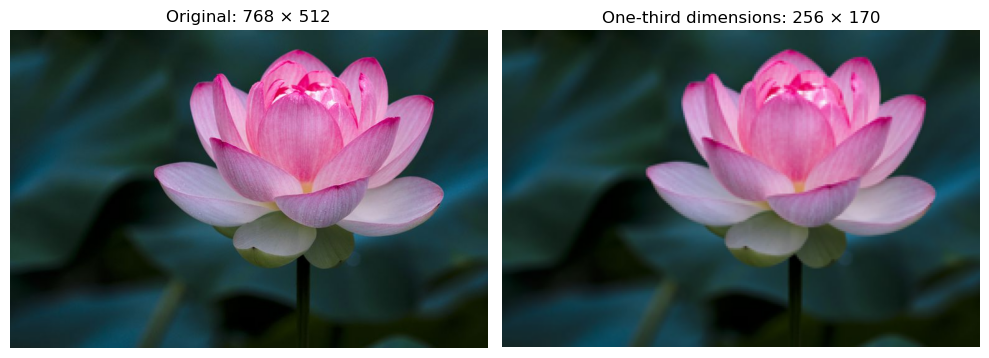

In [3]:
width, height = flower.size
resized = flower.resize((width // 3, height // 3))
print(f"Original (width, height): {flower.size}; array shape: {np.asarray(flower).shape}")
print(f"Resized (width, height): {resized.size}; array shape: {np.asarray(resized).shape}")
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, image, title in zip(axes, [flower, resized], ["Original", "One-third dimensions"]):
    ax.imshow(image)
    ax.set_title(f"{title}: {image.size[0]} × {image.size[1]}")
    ax.axis("off")
fig.tight_layout()
plt.show()

## (b) Grayscale and black-and-white images

Use PIL buil-in convert to convert orignal RGB image to grayscale ('L' mode). For BW transformation, a grayscale pixel is white when $f/255>0.45$ (equivalently $f>114.75$), black otherwise.

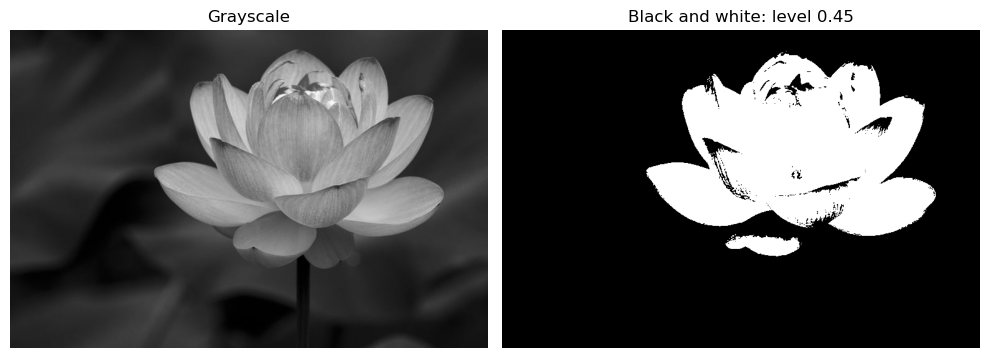

In [6]:
rgb = np.asarray(flower, dtype=float)
gray = flower.convert('L')
f = np.asarray(gray, dtype=float)
binary_045 = np.where(f / 255.0 > 0.45, 255, 0).astype(np.uint8)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, image, title in zip(axes, [gray, binary_045],
                            ["Grayscale", "Black and white: level 0.45"]):
    ax.imshow(image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
fig.tight_layout()
plt.show()

## (c) Grayscale histogram and contrast

The primary contrast measure is $C=f_{\max}-f_{\min}$. Also report Michelson contrast $(f_{\max}-f_{\min})/(f_{\max}+f_{\min})$ and RMS contrast (the population standard deviation).

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

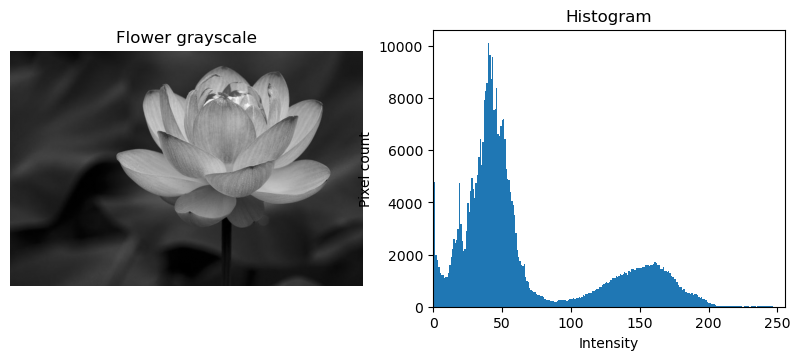

In [7]:
image_and_histogram(gray, "Flower grayscale")
report_contrast(gray, "Contrast")
print(f"Min/max: {gray.min()}, {gray.max()}; mean: {f.mean():.2f}")
print("Percentiles [5,25,50,75,95]:", np.percentile(f, [5, 25, 50, 75, 95]))
for low, high in [(0, 64), (64, 128), (128, 192), (192, 256)]:
    print(f"[{low}, {high}): {np.mean((f >= low) & (f < high)):.1%}")

### Interpretation

The histogram has a dominant dark peak around 40 and a smaller broad bright population around 150–170, consistent with the dark background and brighter flower. About 71.0% of pixels are below 64, and only 1.0% are at least 192. The median is 46 and mean is 66.94, so this is predominantly a dark image despite spanning the full 0–255 range.

Original contrast: range **255**, Michelson **1.000000**, RMS **51.660962**. The range measures only extreme intensities and does not imply uniformly strong local contrast. A histogram alone cannot identify spatial boundaries.

## (d) Transformations

Each image is displayed using the same fixed [0,255] scale so automatic display normalization cannot hide brightness changes.

### (d.1) Linear

$g=1.4f-20$.

**Purpose:** Increases differences between intensities before clipping while lowering the intercept; saturation loses detail at the extremes.

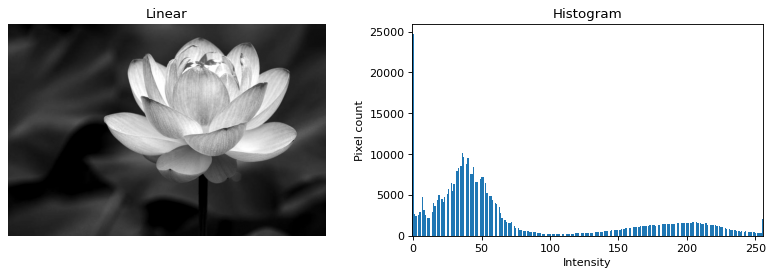

In [ ]:
linear = to_uint8(1.4 * f - 20)
image_and_histogram(linear, "Linear")

### (d.2) Log

$g=40\ln(1+f)$.

**Purpose:** Expands differences among low intensities and compresses differences among high intensities; with this coefficient the maximum possible output is about 222.

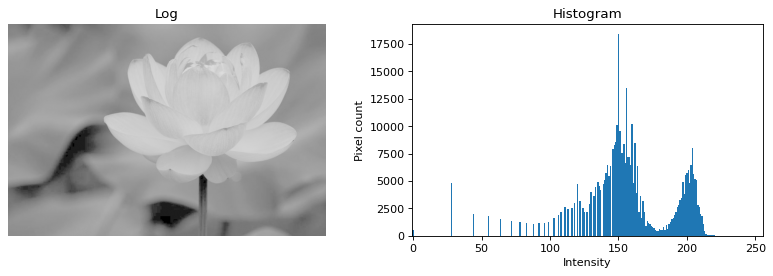

In [ ]:
log_image = to_uint8(40 * np.log1p(f))
image_and_histogram(log_image, "Log")

### (d.3) Power law

$g=0.1f^{1.4}$.

**Purpose:** Darkens nonzero intensities on this 0–255 scale and gives relatively more separation to brighter inputs than darker inputs.

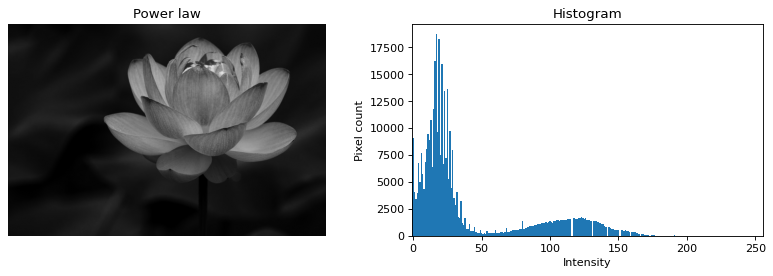

In [ ]:
power_image = to_uint8(0.1 * f ** 1.4)
image_and_histogram(power_image, "Power law")

### (d.4) Threshold

$g=255$ for $f>120$, and $g=0$ otherwise.

**Purpose:** Separates pixels into two intensity classes, discarding within-class grayscale detail.

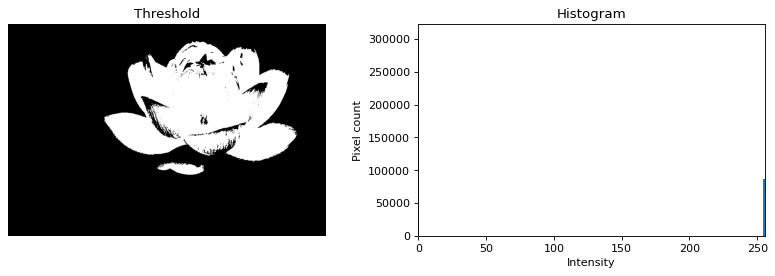

In [ ]:
threshold_image = np.where(f > 120, 255, 0).astype(np.uint8)
image_and_histogram(threshold_image, "Threshold")

### (d.5) Histogram shift

$g=\operatorname{clip}_{[0,255]}(f+50\,\mathbf{1}_{\{25\le f\le225\}})$ under the interval-selective convention stated above.

**Purpose:** Brightens the selected intensity band while retaining values outside it, with possible saturation and discontinuities at the band boundaries.

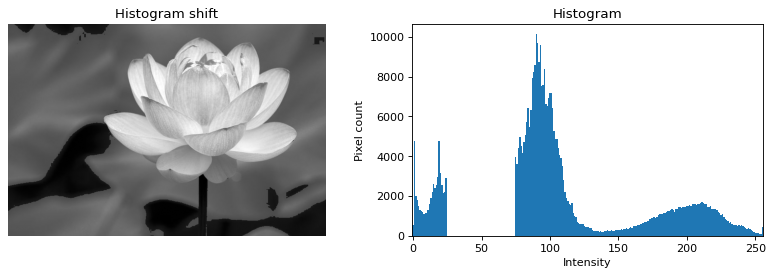

In [ ]:
shift_mask = (f >= 25) & (f <= 225)
shift_image = to_uint8(f + 50 * shift_mask)
image_and_histogram(shift_image, "Histogram shift")

### (d.6) Histogram stretch

$g=235(f-f_{\min})/(f_{\max}-f_{\min})$. A constant image is mapped to zero to avoid division by zero.

**Purpose:** Maps the observed intensity endpoints to 0 and 235; this expands the range only if the original range is below 235 and otherwise compresses it.

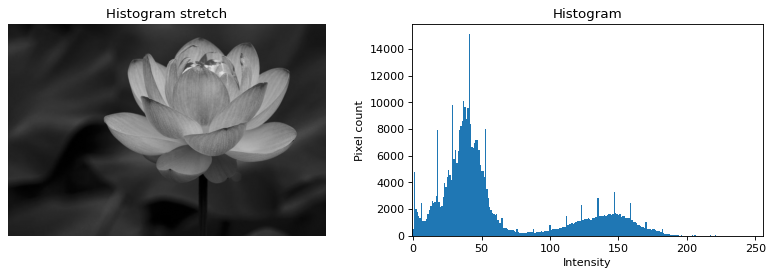

Before stretch: range=255, Michelson=1.000000, RMS=51.660962
After stretch: range=235, Michelson=1.000000, RMS=47.599638


In [ ]:
span = np.ptp(f)
stretched = to_uint8(235 * (f - f.min()) / span) if span else np.zeros_like(gray)
image_and_histogram(stretched, "Histogram stretch")
report_contrast(gray, "Before stretch")
report_contrast(stretched, "After stretch")

## Validation

Check output shapes, clipping, threshold boundaries, interval-shift boundaries, and stretch endpoints.

In [ ]:
outputs = [linear, log_image, power_image, threshold_image, shift_image, stretched]
for image in outputs:
    assert image.shape == gray.shape
    assert image.dtype == np.uint8
    assert np.isfinite(image).all()
assert set(np.unique(binary_045)).issubset({0, 255})
assert set(np.unique(threshold_image)).issubset({0, 255})
assert np.array_equal(shift_image[~shift_mask], gray[~shift_mask])
probe = np.array([0., 24., 25., 120., 205., 225., 226., 255.])
assert np.array_equal(to_uint8(probe + 50 * ((probe >= 25) & (probe <= 225))),
                      [0, 24, 75, 170, 255, 255, 226, 255])
assert np.array_equal(to_uint8(np.array([-20., 0., 255., 300.])), [0, 0, 255, 255])
if span:
    assert stretched.min() == 0 and stretched.max() == 235
assert np.array_equal(np.asarray(flower, dtype=float), rgb)
print("All validation checks passed.")

All validation checks passed.


## Results summary

Original dimensions: **768 × 512** (width × height). Resized dimensions: **256 × 171**.

Stretch under the stated convention: range **255 → 235**, Michelson **1 → 1**, RMS **51.660962 → 47.599638**. Thus this particular operation compresses the dynamic range rather than improving contrast.

Validation: all code cells executed sequentially in a headless Python process, including all assertions; notebook structure validated with `nbformat`. Outputs below are captured from that execution, not from a Jupyter kernel (kernel startup was unavailable in the validation environment).